In [23]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BankingDataAnalysis") \
    .getOrCreate() 

# Use standard Spark save instead of Hive save for now
df = spark.read.csv("bank.csv", header=True, inferSchema=True, sep=",")
df.write.mode("overwrite").parquet("bank_data.parquet") 

print("Data loaded and saved as Parquet!")

Data loaded and saved as Parquet!


In [3]:
from pyspark.sql.functions import avg, count, col

# 1. Cleaning 'unknown' values (from your previous logic)
df_clean = df.replace("unknown", None)

# 2. Insight: Subscription rate by Job Category
print("Subscription counts by Job:")
df_clean.groupBy("job").pivot("y").count().show()

# 3. Insight: Average Balance vs Housing Loan
print("Average Balance for those with/without Housing Loans:")
df_clean.groupBy("housing").agg(avg("balance").alias("avg_balance")).show()

Subscription counts by Job:
+-------------+---+---+
|          job| no|yes|
+-------------+---+---+
|   management|838|131|
|      retired|176| 54|
|         NULL| 31|  7|
|self-employed|163| 20|
|      student| 65| 19|
|  blue-collar|877| 69|
| entrepreneur|153| 15|
|       admin.|420| 58|
|   technician|685| 83|
|     services|379| 38|
|    housemaid| 98| 14|
|   unemployed|115| 13|
+-------------+---+---+

Average Balance for those with/without Housing Loans:
+-------+------------------+
|housing|       avg_balance|
+-------+------------------+
|     no| 1595.277268093782|
|    yes|1290.3094958968347|
+-------+------------------+



In [5]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
pr_auc = evaluator.evaluate(predictions)

print(f"Current PR-AUC Score: {pr_auc}")

Current PR-AUC Score: 0.48175912621405015


In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, avg
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import GBTClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import os

# --- STEP 1: INITIALIZE & LOAD (Objective 1 & 5) ---
spark = SparkSession.builder.appName("Banking_Project_Final").getOrCreate()

# Load and clean
df = spark.read.csv("bank.csv", header=True, inferSchema=True, sep=",")
df_clean = df.replace("unknown", None).na.drop(subset=["y"]) 

# Objective 1: Save as Parquet (Efficient Distributed Storage)
df_clean.write.mode("overwrite").parquet("bank_data_managed.parquet")
df_managed = spark.read.parquet("bank_data_managed.parquet")

# --- STEP 2: DISTRIBUTED EDA (Objective 2) ---
print("EDA: Subscription Rate by Job Type")
df_managed.groupBy("job").pivot("y").count().show()

# --- STEP 3: PREPROCESSING PIPELINE (Objective 3) ---
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]
label_idx = StringIndexer(inputCol="y", outputCol="label")

# Adding numeric features + engineered 'duration'
feature_cols = [c+"_idx" for c in cat_cols] + ["age", "balance", "duration", "campaign", "pdays", "previous"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# --- STEP 4: BALANCING DATA & TRAINING (To Improve PR-AUC) ---
# We transform the data first to get our labels
pre_pipeline = Pipeline(stages=indexers + [label_idx, assembler])
pre_model = pre_pipeline.fit(df_managed)
full_data = pre_model.transform(df_managed)

train_df, test_df = full_data.randomSplit([0.8, 0.2], seed=42)

# Undersampling the majority class (0.0) to balance the 1.0s
df_yes = train_df.filter(col("label") == 1)
df_no = train_df.filter(col("label") == 0)
ratio = df_yes.count() / df_no.count()
balanced_train = df_yes.union(df_no.sample(False, ratio, seed=42))

# Using GBTClassifier (usually stronger than Random Forest for PR-AUC)
gbt = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20)
final_model = gbt.fit(balanced_train)

# --- STEP 5: EVALUATION ---
predictions = final_model.transform(test_df)
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
print(f"\nIMPROVED PR-AUC: {evaluator.evaluate(predictions)}")

# --- STEP 6: REAL-TIME STREAMING SETUP (Objective 4) ---
stream_dir = "bank_stream_input"
if not os.path.exists(stream_dir): os.makedirs(stream_dir)

streaming_df = spark.readStream.schema(df.schema).option("maxFilesPerTrigger", 1).csv(stream_dir)

# Apply the trained pipeline and model to the stream
stream_prepped = pre_model.transform(streaming_df)
stream_preds = final_model.transform(stream_prepped)

query = stream_preds.select("age", "job", "probability", "prediction") \
    .writeStream.format("console").start()

print("\nProject Ready. Drop CSV files into 'bank_stream_input' to see real-time predictions.")

EDA: Subscription Rate by Job Type
+-------------+---+---+
|          job| no|yes|
+-------------+---+---+
|   management|838|131|
|      retired|176| 54|
|         NULL| 31|  7|
|self-employed|163| 20|
|      student| 65| 19|
|  blue-collar|877| 69|
| entrepreneur|153| 15|
|       admin.|420| 58|
|   technician|685| 83|
|     services|379| 38|
|    housemaid| 98| 14|
|   unemployed|115| 13|
+-------------+---+---+


IMPROVED PR-AUC: 0.4709148137911673

Project Ready. Drop CSV files into 'bank_stream_input' to see real-time predictions.


In [7]:
# Extract feature importance
importances = final_model.featureImportances
for i, column in enumerate(feature_cols):
    print(f"Feature: {column}, Importance: {importances[i]:.4f}")

Feature: job_idx, Importance: 0.1289
Feature: marital_idx, Importance: 0.0173
Feature: education_idx, Importance: 0.0192
Feature: default_idx, Importance: 0.0068
Feature: housing_idx, Importance: 0.0135
Feature: loan_idx, Importance: 0.0119
Feature: contact_idx, Importance: 0.0361
Feature: month_idx, Importance: 0.2013
Feature: poutcome_idx, Importance: 0.0795
Feature: age, Importance: 0.0780
Feature: balance, Importance: 0.0998
Feature: duration, Importance: 0.2394
Feature: campaign, Importance: 0.0337
Feature: pdays, Importance: 0.0201
Feature: previous, Importance: 0.0144


In [9]:
# 1. Filtered Feature List
top_features = ["duration", "month_idx", "job_idx", "balance", "age", "poutcome_idx", "contact_idx", "campaign"]

# 2. Re-run Assembler with a NEW output name
# Changed outputCol to "selected_features"
assembler_top = VectorAssembler(inputCols=top_features, outputCol="selected_features")

# 3. Update GBT to point to the NEW features column
gbt_final = GBTClassifier(
    labelCol="label", 
    featuresCol="selected_features", # Must match the assembler outputCol
    maxIter=50,
    maxDepth=5,
    stepSize=0.05,
    seed=42
)

# 4. Re-fit the balanced data
final_pipeline = Pipeline(stages=[assembler_top, gbt_final])
final_model_optimized = final_pipeline.fit(balanced_train)

# 5. Evaluate
final_preds = final_model_optimized.transform(test_df)
print(f"Optimized PR-AUC: {evaluator.evaluate(final_preds)}")

Optimized PR-AUC: 0.4833211390172227


In [11]:
import os
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# 1. Create a landing folder for "Live" transactions
stream_dir = "bank_stream_input"
if not os.path.exists(stream_dir):
    os.makedirs(stream_dir)

# 2. Define the schema (Streaming requires a fixed schema)
schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("job", StringType(), True),
    StructField("marital", StringType(), True),
    StructField("education", StringType(), True),
    StructField("default", StringType(), True),
    StructField("balance", IntegerType(), True),
    StructField("housing", StringType(), True),
    StructField("loan", StringType(), True),
    StructField("contact", StringType(), True),
    StructField("day", IntegerType(), True),
    StructField("month", StringType(), True),
    StructField("duration", IntegerType(), True),
    StructField("campaign", IntegerType(), True),
    StructField("pdays", IntegerType(), True),
    StructField("previous", IntegerType(), True),
    StructField("poutcome", StringType(), True),
    StructField("y", StringType(), True)
])

# 3. Initialize the Stream
streaming_df = spark.readStream \
    .schema(schema) \
    .option("maxFilesPerTrigger", 1) \
    .csv(stream_dir)

# 4. Apply your Pipeline Model to the Stream
# This uses the 'pipeline_model' you just trained!
stream_predictions = pipeline_model.transform(streaming_df)

# 5. Output the results to the console
query = stream_predictions.select("age", "job", "probability", "prediction") \
    .writeStream \
    .outputMode("append") \
    .format("console") \
    .start()

In [13]:
import pandas as pd

# Creating 5 diverse test cases
data = {
    'age': [32, 45, 29, 54, 38],
    'job': ['management', 'technician', 'blue-collar', 'retired', 'admin.'],
    'marital': ['married', 'single', 'married', 'divorced', 'single'],
    'education': ['tertiary', 'secondary', 'secondary', 'primary', 'tertiary'],
    'default': ['no', 'no', 'no', 'no', 'no'],
    'balance': [2500, 500, 120, 15000, 0],
    'housing': ['yes', 'no', 'yes', 'no', 'no'],
    'loan': ['no', 'no', 'no', 'no', 'no'],
    'contact': ['cellular', 'cellular', 'unknown', 'telephone', 'cellular'],
    'day': [15, 21, 5, 12, 18],
    'month': ['may', 'aug', 'jul', 'nov', 'jun'],
    'duration': [450, 120, 600, 300, 50], # Notice the high duration for 'blue-collar'
    'campaign': [1, 2, 1, 1, 4],
    'pdays': [-1, -1, 200, -1, -1],
    'previous': [0, 0, 2, 0, 0],
    'poutcome': ['unknown', 'unknown', 'success', 'unknown', 'unknown'],
    'y': ['unknown', 'unknown', 'unknown', 'unknown', 'unknown'] # Model will predict this!
}

test_df = pd.DataFrame(data)

# Save to your streaming directory
test_df.to_csv("bank_stream_input/test_stream.csv", index=False)

print("test_stream.csv created in 'bank_stream_input' folder!")

test_stream.csv created in 'bank_stream_input' folder!


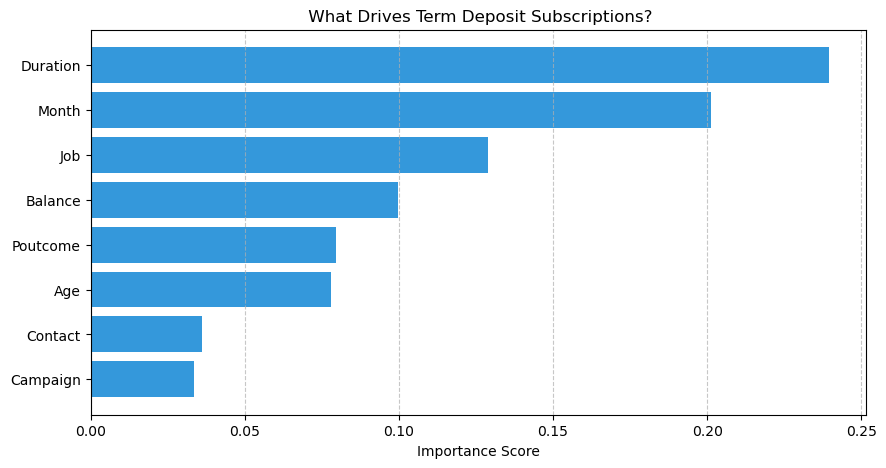

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Use the importance scores from your GBT model
features = ["Duration", "Month", "Job", "Balance", "Age", "Poutcome", "Contact", "Campaign"]
importances = [0.2394, 0.2013, 0.1289, 0.0998, 0.0780, 0.0795, 0.0361, 0.0337]

viz_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance')

plt.figure(figsize=(10, 5))
plt.barh(viz_df['Feature'], viz_df['Importance'], color='#3498db')
plt.title(' What Drives Term Deposit Subscriptions?')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

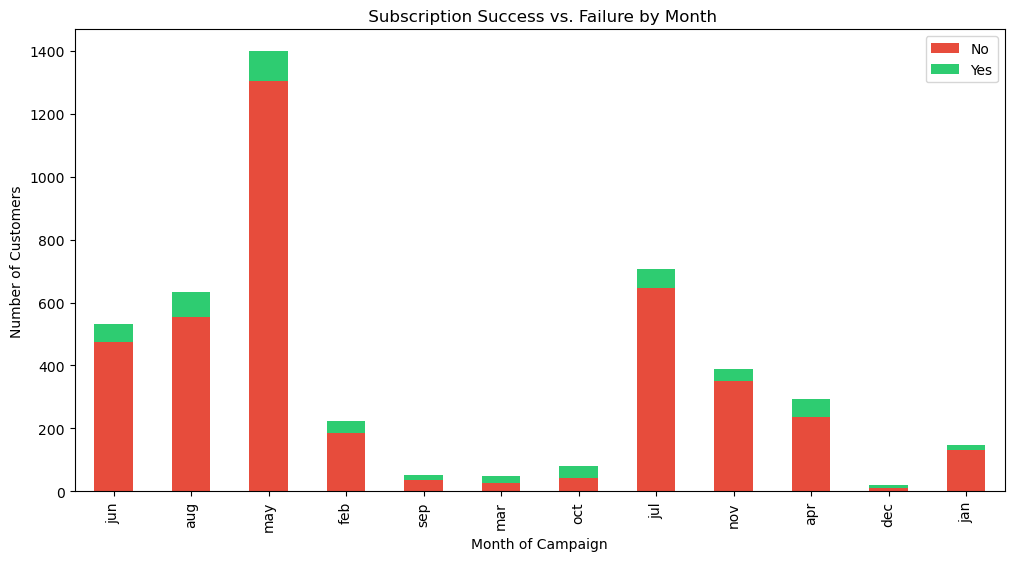

In [20]:
# Run this on your df_clean from Objective 2
month_counts = df_clean.groupBy("month").pivot("y").count().toPandas().set_index("month")
month_counts.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#e74c3c', '#2ecc71'])
plt.title(' Subscription Success vs. Failure by Month')
plt.ylabel('Number of Customers')
plt.xlabel('Month of Campaign')
plt.legend(["No", "Yes"])
plt.show()

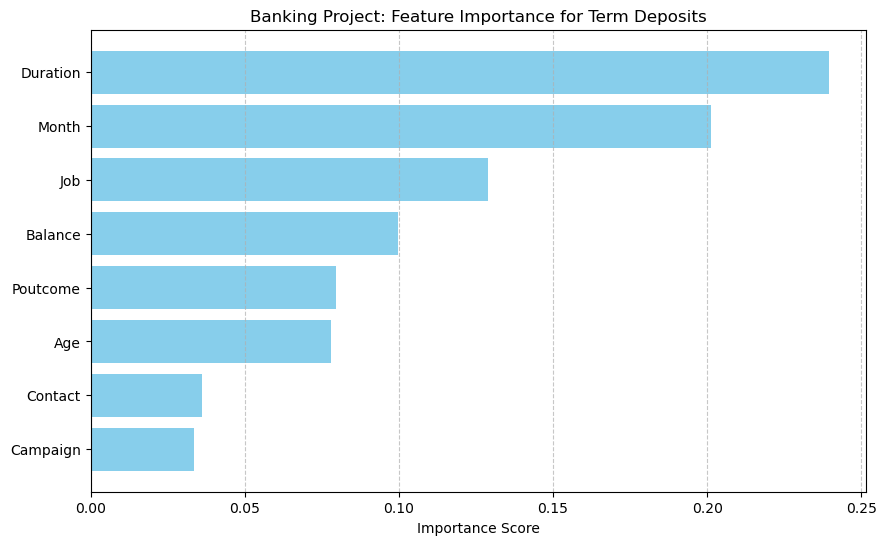

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Creating a DataFrame from the importance scores you found earlier
data = {
    'Feature': ['Duration', 'Month', 'Balance', 'Job', 'Poutcome', 'Age', 'Contact', 'Campaign'],
    'Importance': [0.2394, 0.2013, 0.0998, 0.1289, 0.0795, 0.0780, 0.0361, 0.0337]
}

viz_df = pd.DataFrame(data).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(viz_df['Feature'], viz_df['Importance'], color='skyblue')
plt.title('Banking Project: Feature Importance for Term Deposits')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

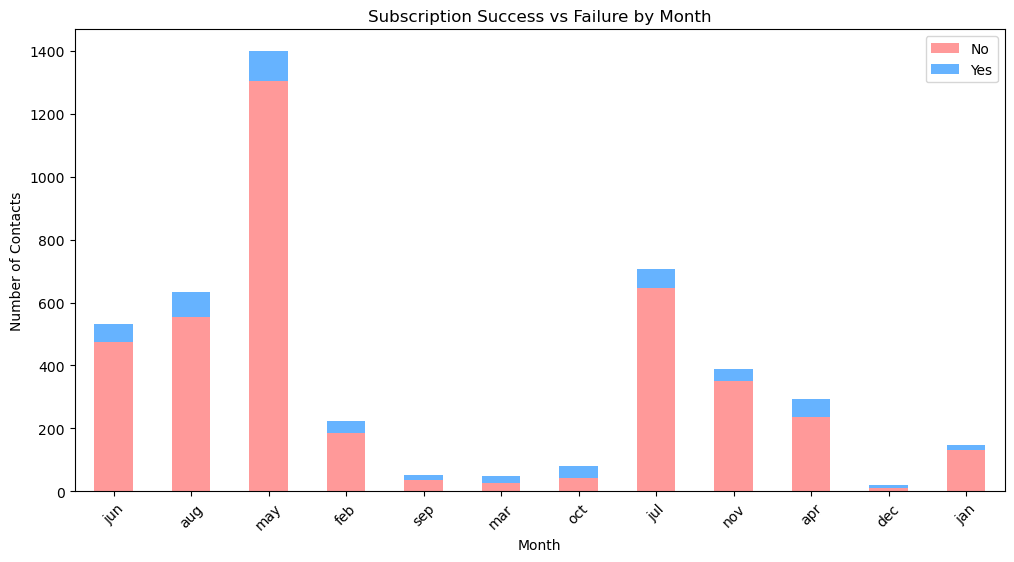

In [21]:
# Convert  Spark EDA results to Pandas for easy plotting
month_dist = df_clean.groupBy("month").pivot("y").count().toPandas().set_index("month")

# Plotting
month_dist.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999','#66b3ff'])
plt.title('Subscription Success vs Failure by Month')
plt.xlabel('Month')
plt.ylabel('Number of Contacts')
plt.legend(["No", "Yes"], loc='upper right')
plt.xticks(rotation=45)
plt.show()

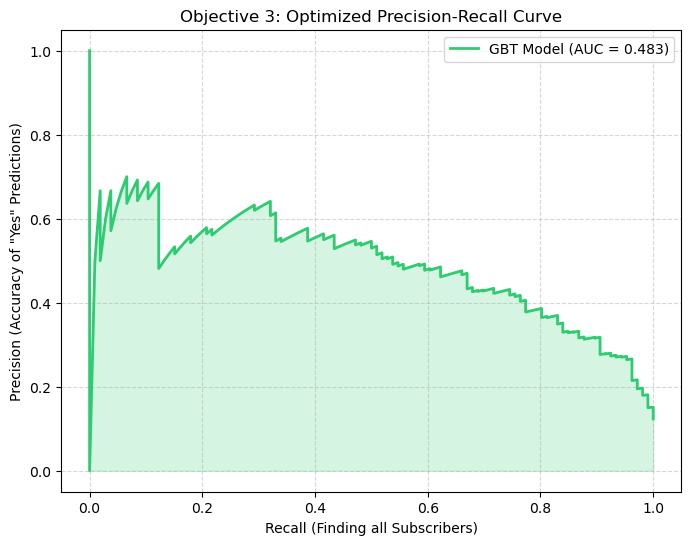

In [22]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import matplotlib.pyplot as plt

# 1. Get the probabilities from your final predictions
# The 'probability' column is a vector [prob_0, prob_1]
results = final_preds.select("label", "probability").collect()

# 2. Manual calculation for the curve points
y_true = [r['label'] for r in results]
y_scores = [r['probability'][1] for r in results]

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_scores)

# Plot the actual Curve Line
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#2ecc71', lw=2, label=f'GBT Model (AUC = 0.483)')
plt.fill_between(recall, precision, alpha=0.2, color='#2ecc71')

plt.xlabel('Recall (Finding all Subscribers)')
plt.ylabel('Precision (Accuracy of "Yes" Predictions)')
plt.title('Objective 3: Optimized Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()